In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

In [2]:
spread = xr.open_dataarray('data/TIGGEspread.nc')
dim = xr.open_dataset('data/dim.nc')

In [3]:
intersection = np.sort(np.intersect1d(spread.time.data, dim.initial_time))

spread = spread.sel(time = intersection)
dim = dim.sel(initial_time = intersection)

In [4]:
spread = spread.isel(step = range(5))

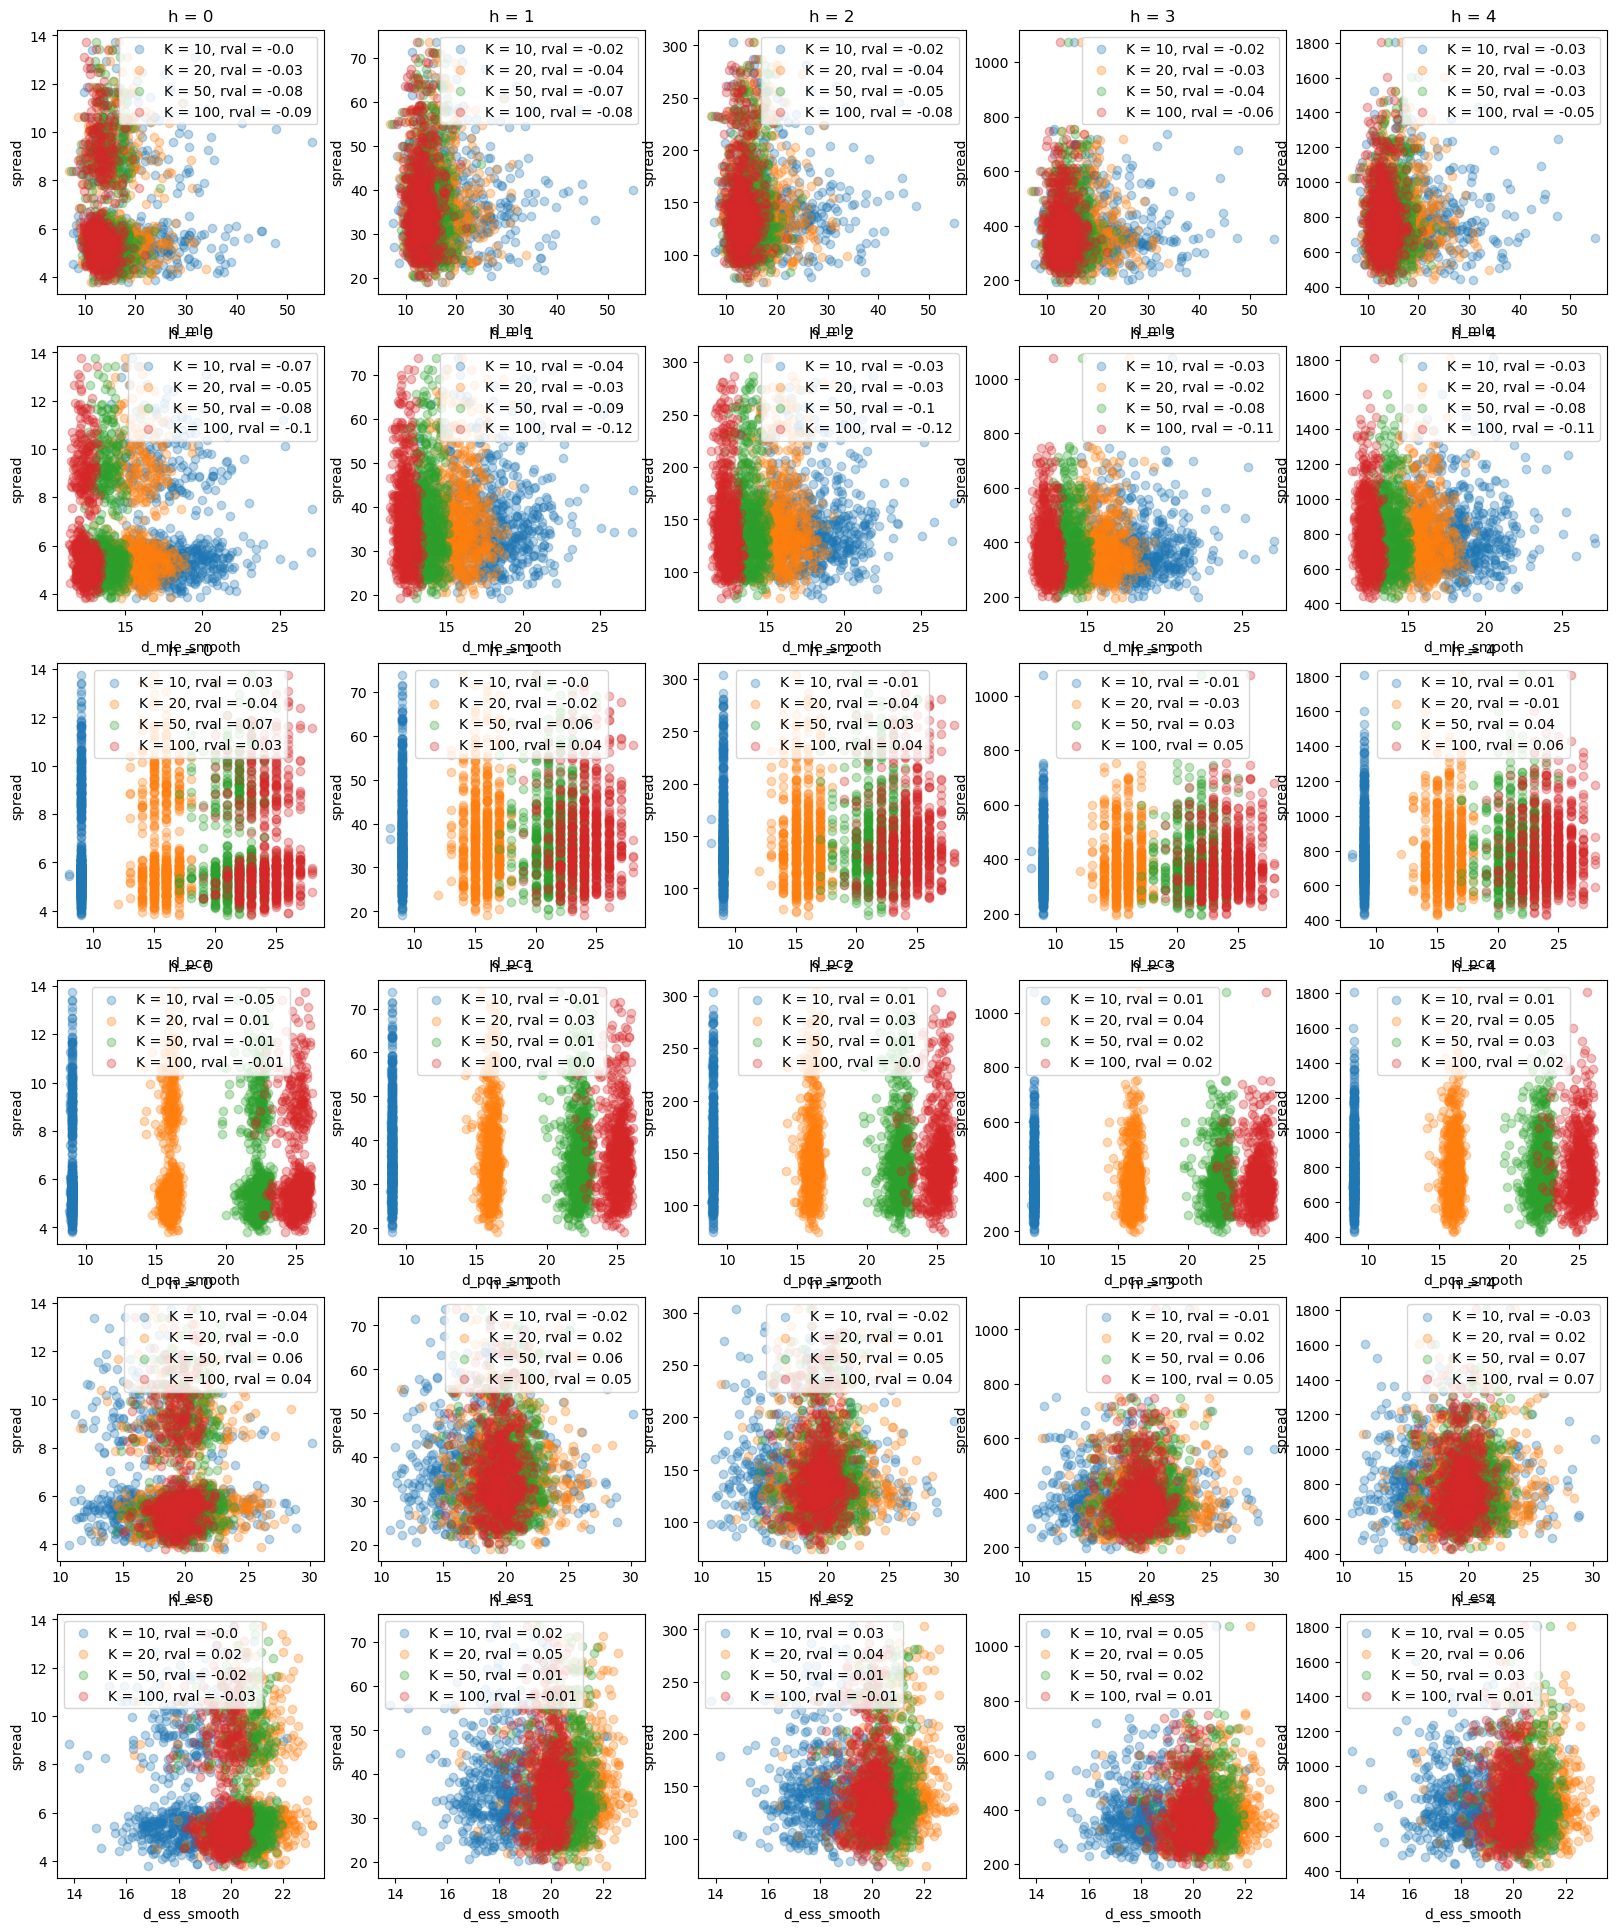

In [5]:
nrows = len(dim)
ncols =  len(spread.step)
fig, axs = plt.subplots(nrows, ncols, figsize = (4 * ncols, 4 * nrows))

for d, di in enumerate(dim):
    for s, step in enumerate(spread.step):
        for k, K in enumerate(dim.K):
            x = dim[di].isel(K = k).data.squeeze()
            y = spread.isel(step = s).data.squeeze()
            reg = linregress(x, y)
            axs[d, s].scatter(x, y, label = f'K = {K.data}, rval = {np.round(reg.rvalue, 2)}', alpha = 0.3)
        axs[d, s].legend()
        axs[d, s].set_title(f'h = {step.data//np.timedelta64(1, "D")}')
        axs[d, s].set_xlabel(di)
        axs[d, s].set_ylabel('spread')